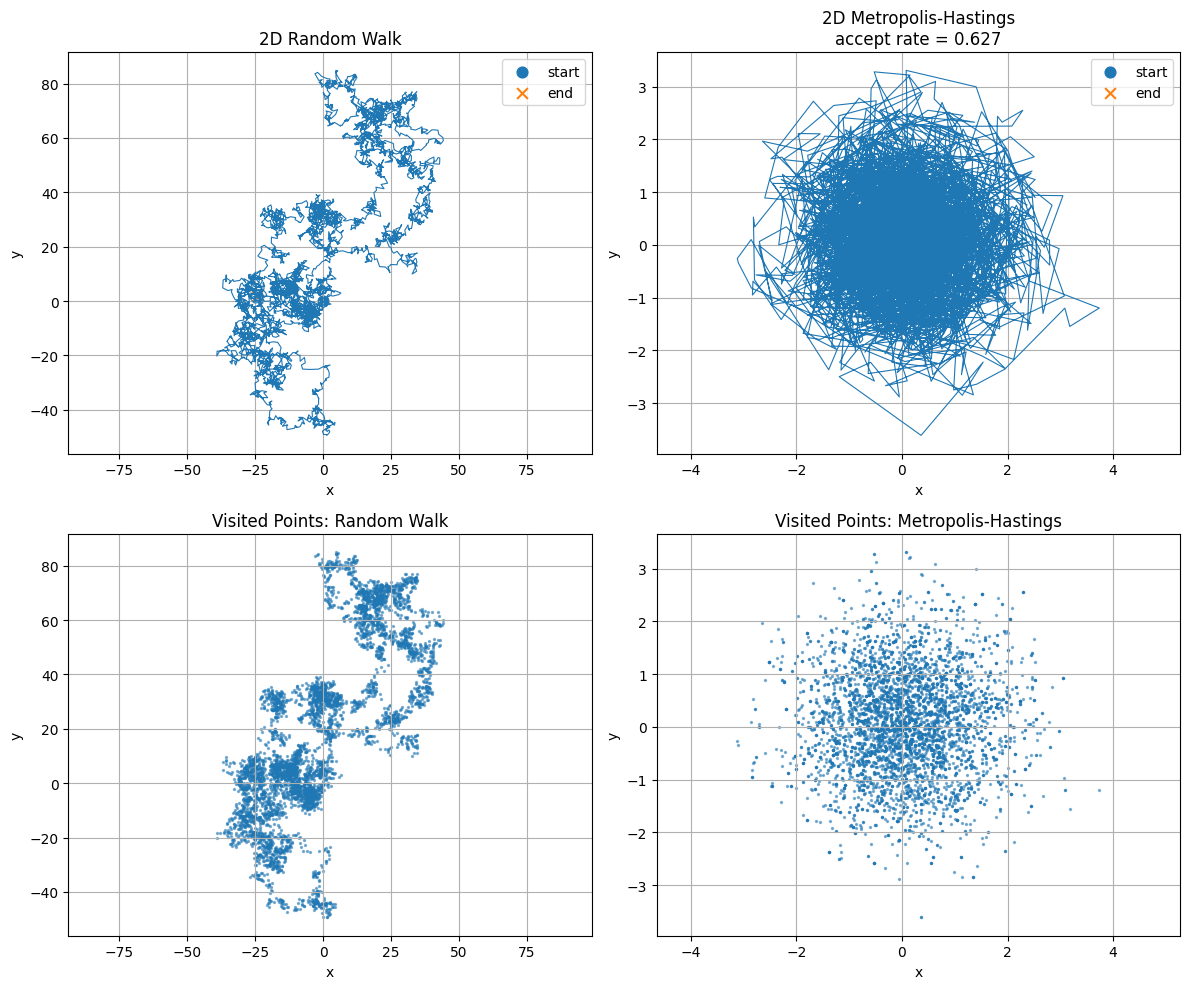

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 設定
# =========================================
np.random.seed(42)
n_steps = 5000
proposal_std = 0.8   # MHの提案分布の幅

# =========================================
# 1. 2次元ランダムウォーク
# =========================================
rw = np.zeros((n_steps, 2))

for t in range(1, n_steps):
    step = np.random.normal(loc=0.0, scale=1.0, size=2)
    rw[t] = rw[t-1] + step

# =========================================
# 2. Metropolis-Hastings
#    目標分布: 2次元標準正規分布
#    pi(x, y) ∝ exp(-(x^2 + y^2)/2)
# =========================================
def log_target(x):
    return -0.5 * (x[0]**2 + x[1]**2)

mh = np.zeros((n_steps, 2))
current = np.array([0.0, 0.0])
accepted = 0

for t in range(1, n_steps):
    proposal = current + np.random.normal(0, proposal_std, size=2)

    log_alpha = log_target(proposal) - log_target(current)
    if np.log(np.random.rand()) < log_alpha:
        current = proposal
        accepted += 1

    mh[t] = current

accept_rate = accepted / (n_steps - 1)

# =========================================
# 3. 結果表示
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ---- 左上: ランダムウォークの軌跡 ----
axes[0, 0].plot(rw[:, 0], rw[:, 1], linewidth=0.8)
axes[0, 0].scatter(rw[0, 0], rw[0, 1], s=60, marker='o', label='start')
axes[0, 0].scatter(rw[-1, 0], rw[-1, 1], s=60, marker='x', label='end')
axes[0, 0].set_title("2D Random Walk")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].legend()
axes[0, 0].axis("equal")
axes[0, 0].grid(True)

# ---- 右上: MHの軌跡 ----
axes[0, 1].plot(mh[:, 0], mh[:, 1], linewidth=0.8)
axes[0, 1].scatter(mh[0, 0], mh[0, 1], s=60, marker='o', label='start')
axes[0, 1].scatter(mh[-1, 0], mh[-1, 1], s=60, marker='x', label='end')
axes[0, 1].set_title(f"2D Metropolis-Hastings\naccept rate = {accept_rate:.3f}")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
axes[0, 1].legend()
axes[0, 1].axis("equal")
axes[0, 1].grid(True)

# ---- 左下: ランダムウォークの訪問点 ----
axes[1, 0].scatter(rw[:, 0], rw[:, 1], s=2, alpha=0.5)
axes[1, 0].set_title("Visited Points: Random Walk")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
axes[1, 0].axis("equal")
axes[1, 0].grid(True)

# ---- 右下: MHの訪問点 ----
axes[1, 1].scatter(mh[:, 0], mh[:, 1], s=2, alpha=0.5)
axes[1, 1].set_title("Visited Points: Metropolis-Hastings")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
axes[1, 1].axis("equal")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

ランダムウォークは毎回ただ足し合わせるだけなので、時間がたつほど外へ広がりやすいです。
一方、MH は提案点を出したあとで「その場所は目標分布的にもっともらしいか」を判定するので、原点付近に集まりやすくなります。
つまり、見た目はどちらも「少しずつ動く点」ですが、MH は単なるランダム移動ではなく、分布に従うように設計された確率的探索です。